# Predictor and lead time selection, region concatenation

In [1]:
import os
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier, plot_importance
import seaborn as sns
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import shap
import numpy as np
# must be set so that figures do not get cut off
plt.rcParams['figure.autolayout'] = True

In [2]:
# import drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ML_data_eea_mam = '/content/drive/My Drive/capstone_data/ml_data_automation_test_v2/eastern_east_africa_MAM_ml_data_seasonal.csv'
ML_data_eea_OND = '/content/drive/My Drive/capstone_data/ml_data_automation_test_v2/eastern_east_africa_OND_ml_data_seasonal.csv'
ML_data_sa_DJF = '/content/drive/My Drive/capstone_data/ml_data_automation_test_v2/southern_africa_DJF_ml_data_seasonal.csv'

In [4]:
# open the csv files
eea_mam = pd.read_csv(ML_data_eea_mam)
eea_OND = pd.read_csv(ML_data_eea_OND)
sa_DJF = pd.read_csv(ML_data_sa_DJF)

In [5]:
# concatenate the different regions
df = pd.concat([eea_mam, eea_OND, sa_DJF], ignore_index=True)

In [6]:
df

,year,season,region,precip,tercile,nino_34_L1,nino_4_L1,western_west_v_L1,northern_west_v_L1,southern_west_v_L1,...,IOD_west_L7,IOD_east_L7,nino_34_L8,nino_4_L8,western_west_v_L8,northern_west_v_L8,southern_west_v_L8,SWIO_L8,IOD_west_L8,IOD_east_L8
0,1981,MAM,eastern_east_africa,114.613840,an,-0.637298,-0.166301,-0.843808,-1.275156,-0.524595,...,-0.463903,-0.781562,-0.000128,0.180068,-0.987879,-1.261318,-1.399026,-0.168292,-0.751203,-0.150157
1,1982,MAM,eastern_east_africa,85.274994,an,-0.146463,-0.170383,-0.833016,-0.977030,-0.487737,...,-0.886227,0.219707,-0.866118,-1.235995,0.180759,-0.349686,-0.977762,-0.379167,-0.869233,0.157105
2,1983,MAM,eastern_east_africa,60.665314,n,2.008656,0.497252,-1.586229,-1.747350,-2.291930,...,0.010555,-1.113700,0.637925,0.391133,-2.249874,-1.411861,-1.020552,-0.084088,-0.180941,-1.284622
3,1984,MAM,eastern_east_africa,46.708668,bn,-0.177245,-0.849678,-0.248746,-0.041805,-0.675279,...,0.708759,-0.369506,-0.060626,-0.366909,-1.238808,-1.525265,-1.061650,1.605686,1.644259,-0.689016
4,1985,MAM,eastern_east_africa,86.907720,an,-0.726995,-0.858779,-0.747452,-0.736692,0.418809,...,-1.971461,-1.184233,-0.670569,-0.979976,-1.152614,0.531464,-0.933960,-0.968778,-2.396664,-0.888452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,2020,DJF,southern_africa,195.248960,an,-1.184470,-0.996108,1.070066,1.203739,0.963815,...,1.585993,0.499144,0.707527,1.041360,1.315834,1.040455,1.013086,-1.327554,1.466640,1.567257
128,2021,DJF,southern_africa,171.948970,an,-0.783120,-0.733212,1.881630,2.046534,1.917287,...,-0.391996,0.442665,-1.061403,-0.556117,0.912634,1.408810,0.702447,-0.092421,-0.016909,-0.493938
129,2022,DJF,southern_africa,130.848660,bn,-0.740807,-1.109923,2.160137,1.126073,1.668400,...,-0.051227,1.227015,-1.687536,-1.261661,1.166735,1.500176,1.817290,0.866893,0.102911,1.045731
130,2023,DJF,southern_africa,152.274870,n,1.760639,1.875717,0.761358,1.546467,-0.264205,...,0.669255,0.493774,0.329411,0.356894,1.863500,0.913423,0.951054,1.666059,1.246867,0.248940


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:19:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Classification Report ===
              precision    recall  f1-score   support

          an       1.00      1.00      1.00         2
          bn       1.00      1.00      1.00         2
           n       0.00      0.00      0.00         0

    accuracy                           1.00         4
   macro avg       0.67      0.67      0.67         4
weighted avg       1.00      1.00      1.00         4



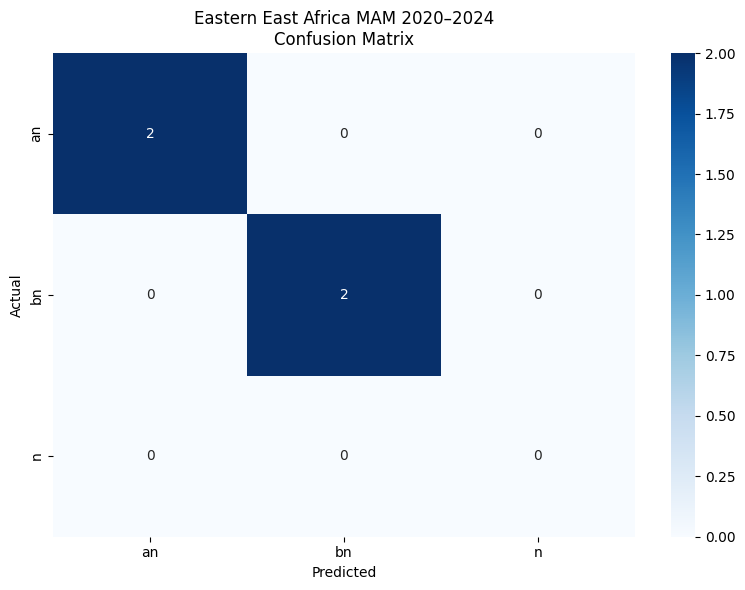

<Figure size 2000x1200 with 0 Axes>

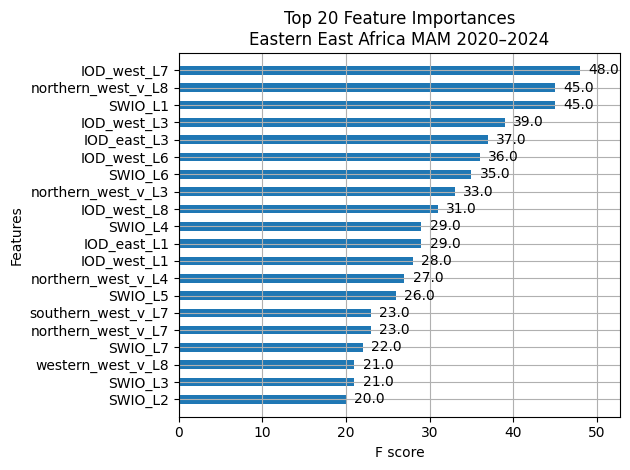

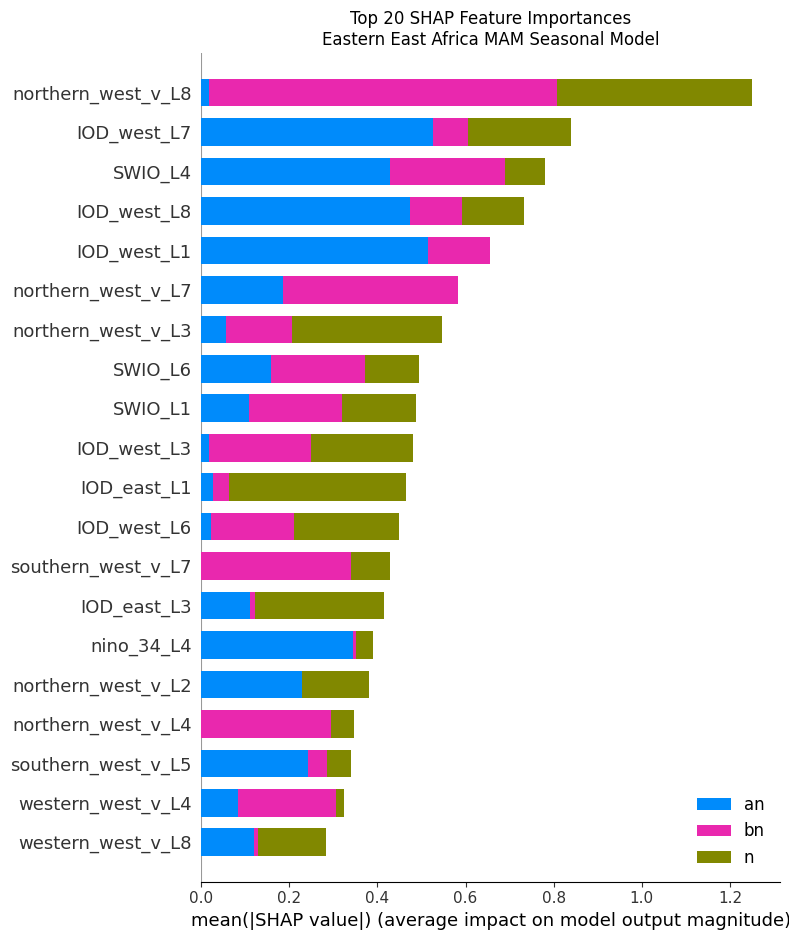


=== Probabilistic Forecast Details ===
 year  proba_an  proba_bn  proba_n true_label predicted_label
 2021  0.333258  0.519513 0.147228         bn              bn
 2022  0.070249  0.540582 0.389169         bn              bn
 2023  0.935329  0.030021 0.034650         an              an
 2024  0.902005  0.050202 0.047793         an              an


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ml dataset with 3 regions
df = pd.concat([eea_mam, eea_OND, sa_DJF], ignore_index=True)

# Drop precip column if it exists
if 'precip' in df.columns:
    df.drop(columns=['precip'], inplace=True)

# Encode categorical columns
season_encoder = LabelEncoder()
region_encoder = LabelEncoder()

# Fit encoders
season_encoder.fit(df['season'])
region_encoder.fit(df['region'])

# Transform specific labels for filtering
encoded_MAM = season_encoder.transform(['MAM'])[0]
encoded_EEA = region_encoder.transform(['eastern_east_africa'])[0]

# Encode the columns
df['season'] = season_encoder.transform(df['season'])
df['region'] = region_encoder.transform(df['region'])

# Select training and test years

# Training only has data from 1981-2020
train_years = list(range(1981, 2021))

# Testing only has data from 2021-2024
test_years = list(range(2021, 2025))

# Split into training and test sets
train_df = df[df['year'].isin(train_years)]

# Test set only has EEA MAM
test_df = df[
    (df['year'].isin(test_years)) &
    (df['season'] == encoded_MAM) &
    (df['region'] == encoded_EEA)
]

# Separate features and labels (drop season, and year as predictors)
X_train = train_df.drop(columns=['tercile', 'season', 'year'])
X_test = test_df.drop(columns=['tercile', 'season', 'year'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode target labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Train XGBoost model
model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
model.fit(X_train, y_train_enc)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Print classification report
print(f"\n=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],
    target_names=label_encoder.classes_,
    zero_division=0
))

# Plot confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Eastern East Africa MAM 2020–2024\nConfusion Matrix')
plt.tight_layout()
plt.show()

# Plot feature importance
plt.figure(figsize=(20, 12))
plot_importance(model, max_num_features=20, importance_type='weight', height=0.5)
plt.title('Top 20 Feature Importances\nEastern East Africa MAM 2020–2024')
plt.tight_layout()
plt.show()

# SHAP explanations
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Assumes explainer and shap_values already defined
plt.figure(figsize=(20, 12))
shap.summary_plot(shap_values, X_test, class_names=label_encoder.classes_, show=False)
plt.title('Top 20 SHAP Feature Importances\nEastern East Africa MAM Seasonal Model')
plt.tight_layout()
plt.show()


# Probabilistic forecast details
test_info = test_df[['year']].reset_index(drop=True)
proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in label_encoder.classes_])
results_df = pd.concat([test_info, proba_df], axis=1)
results_df['true_label'] = label_encoder.inverse_transform(y_test_enc)
results_df['predicted_label'] = label_encoder.inverse_transform(y_pred)

print("\n=== Probabilistic Forecast Details ===")
print(results_df.to_string(index=False))


SHAP summary for class: an


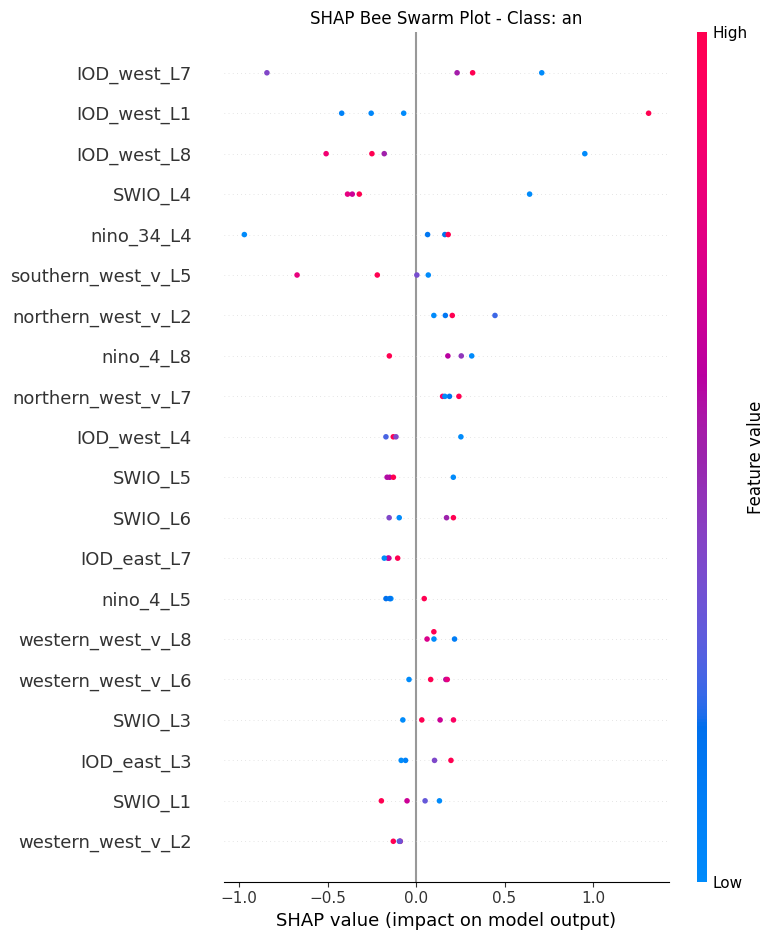

SHAP summary for class: bn


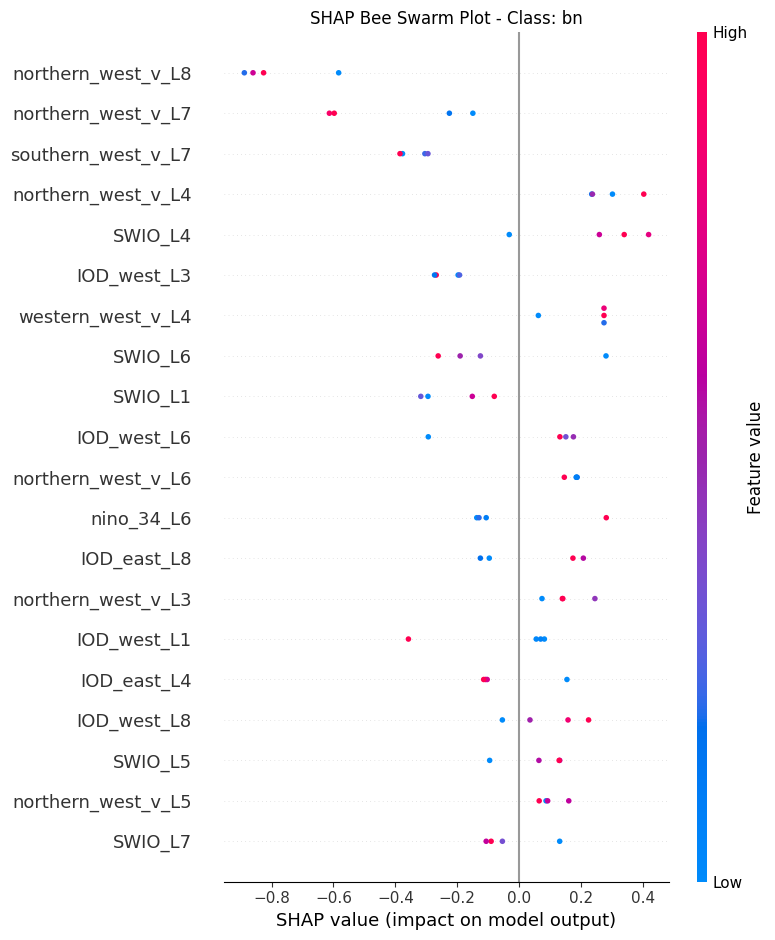

SHAP summary for class: n


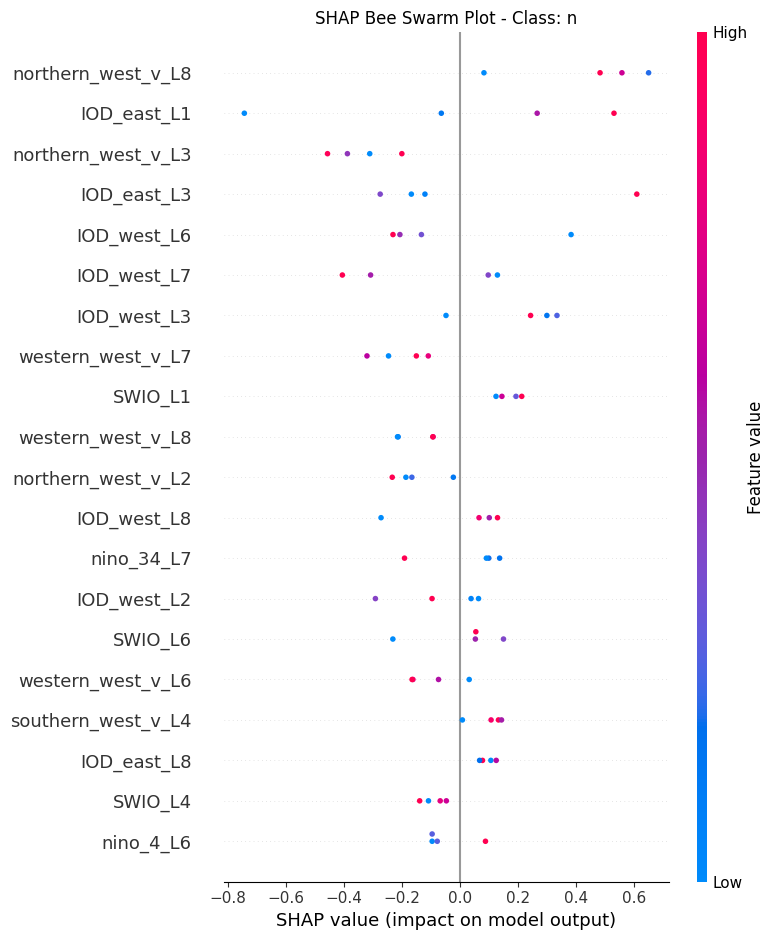

In [10]:
# For each class
for i, class_name in enumerate(label_encoder.classes_):
    print(f"SHAP summary for class: {class_name}")
    plt.figure(figsize=(20, 12))
    shap.summary_plot(
        shap_values[:, :, i],    # SHAP values for class i
        X_test,
        feature_names=X_test.columns if hasattr(X_test, 'columns') else None,
        class_names=[class_name],
        show=False,
        max_display=20
    )
    plt.title(f'SHAP Bee Swarm Plot - Class: {class_name}')
    plt.tight_layout()
    plt.show()
